In [1]:
import pandas as pd
import numpy as np
import os
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import OneHotEncoder,StandardScaler
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.metrics import (mean_absolute_error,mean_squared_error,r2_score)

from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestClassifier, GradientBoostingRegressor, ExtraTreesClassifier
import joblib

In [2]:
file_path= r"C:\Users\gayat\OneDrive\Desktop\CARVISTA\data\raw\archive\train.csv"

df= pd.read_csv(file_path)

print('SHAPE:', df.shape)
print(df.head())

SHAPE: (5847, 14)
   Unnamed: 0                              Name    Location  Year  \
0           1  Hyundai Creta 1.6 CRDi SX Option        Pune  2015   
1           2                      Honda Jazz V     Chennai  2011   
2           3                 Maruti Ertiga VDI     Chennai  2012   
3           4   Audi A4 New 2.0 TDI Multitronic  Coimbatore  2013   
4           6            Nissan Micra Diesel XV      Jaipur  2013   

   Kilometers_Driven Fuel_Type Transmission Owner_Type     Mileage   Engine  \
0              41000    Diesel       Manual      First  19.67 kmpl  1582 CC   
1              46000    Petrol       Manual      First    13 km/kg  1199 CC   
2              87000    Diesel       Manual      First  20.77 kmpl  1248 CC   
3              40670    Diesel    Automatic     Second   15.2 kmpl  1968 CC   
4              86999    Diesel       Manual      First  23.08 kmpl  1461 CC   

       Power  Seats  New_Price  Price  
0  126.2 bhp    5.0        NaN  12.50  
1   88.7 bhp

In [3]:
# Basic information about the dataset

print('Shape:', df.shape)
print('Column Names:')
print(df.columns.tolist())

print('\n' + '='*60)
print('DATA TYPES AND NON-NULL VALUES')
print('='*60)

df.info

print('\n' + '='*60)
print('MISSING VLAUES')
print('='*60)

print(df.isnull().sum())

print('\n' + '='*60)
print('DUPLICATE ROWS')
print('='*60)

print('Number of duplicate rows:', df.duplicated().sum())

Shape: (5847, 14)
Column Names:
['Unnamed: 0', 'Name', 'Location', 'Year', 'Kilometers_Driven', 'Fuel_Type', 'Transmission', 'Owner_Type', 'Mileage', 'Engine', 'Power', 'Seats', 'New_Price', 'Price']

DATA TYPES AND NON-NULL VALUES

MISSING VLAUES
Unnamed: 0              0
Name                    0
Location                0
Year                    0
Kilometers_Driven       0
Fuel_Type               0
Transmission            0
Owner_Type              0
Mileage                 2
Engine                 36
Power                  36
Seats                  38
New_Price            5032
Price                   0
dtype: int64

DUPLICATE ROWS
Number of duplicate rows: 0


In [4]:
print('='*60)
print('NUMERICAL SUMMARY')
print('='*60)

print(df.describe())

NUMERICAL SUMMARY
        Unnamed: 0         Year  Kilometers_Driven        Seats        Price
count  5847.000000  5847.000000       5.847000e+03  5809.000000  5847.000000
mean   3013.181461  2013.448435       5.841013e+04     5.286452     9.653742
std    1736.398890     3.194949       9.237971e+04     0.806668    11.275966
min       1.000000  1998.000000       1.710000e+02     2.000000     0.440000
25%    1509.500000  2012.000000       3.346750e+04     5.000000     3.550000
50%    3015.000000  2014.000000       5.257600e+04     5.000000     5.750000
75%    4517.500000  2016.000000       7.249050e+04     5.000000    10.250000
max    6018.000000  2019.000000       6.500000e+06    10.000000   160.000000


In [5]:
print('='*60)
print('CATEGORICAL COLUMNS')
print('='*60)

categorical_cols= df.select_dtypes(include='object').columns

for col in categorical_cols:
    print(f'\n--- {col} ---')
    print(df[col].value_counts().head(15))

CATEGORICAL COLUMNS

--- Name ---
Name
Mahindra XUV500 W8 2WD        49
Maruti Swift VDI              45
Maruti Swift Dzire VDI        34
Honda City 1.5 S MT           34
Hyundai i10 Sportz            30
Maruti Ritz VDi               30
Toyota Fortuner 3.0 Diesel    29
Hyundai Grand i10 Sportz      27
Honda Amaze S i-Dtech         27
Maruti Ertiga VDI             25
Honda Brio S MT               25
Honda City 1.5 V MT           24
Maruti Wagon R VXI            23
Hyundai Verna 1.6 SX          23
Maruti Wagon R LXI            22
Name: count, dtype: int64

--- Location ---
Location
Mumbai        762
Hyderabad     710
Kochi         640
Coimbatore    631
Pune          590
Delhi         540
Kolkata       525
Chennai       476
Jaipur        403
Bangalore     352
Ahmedabad     218
Name: count, dtype: int64

--- Fuel_Type ---
Fuel_Type
Diesel      3161
Petrol      2684
Electric       2
Name: count, dtype: int64

--- Transmission ---
Transmission
Manual       4135
Automatic    1712
Name: count,

In [6]:
# Creating a working copy

df_clean= df.copy()

print('Original shape:', df_clean.shape)

# Checking missing values

print('\nmissing values before cleaning:')
print(df_clean.isnull().sum())

Original shape: (5847, 14)

missing values before cleaning:
Unnamed: 0              0
Name                    0
Location                0
Year                    0
Kilometers_Driven       0
Fuel_Type               0
Transmission            0
Owner_Type              0
Mileage                 2
Engine                 36
Power                  36
Seats                  38
New_Price            5032
Price                   0
dtype: int64


In [7]:
df.fillna(0)

,Unnamed: 0,Name,Location,Year,Kilometers_Driven,Fuel_Type,Transmission,Owner_Type,Mileage,Engine,Power,Seats,New_Price,Price
0,1,Hyundai Creta 1.6 CRDi SX Option,Pune,2015,41000,Diesel,Manual,First,19.67 kmpl,1582 CC,126.2 bhp,5.0,0,12.50
1,2,Honda Jazz V,Chennai,2011,46000,Petrol,Manual,First,13 km/kg,1199 CC,88.7 bhp,5.0,8.61 Lakh,4.50
2,3,Maruti Ertiga VDI,Chennai,2012,87000,Diesel,Manual,First,20.77 kmpl,1248 CC,88.76 bhp,7.0,0,6.00
3,4,Audi A4 New 2.0 TDI Multitronic,Coimbatore,2013,40670,Diesel,Automatic,Second,15.2 kmpl,1968 CC,140.8 bhp,5.0,0,17.74
4,6,Nissan Micra Diesel XV,Jaipur,2013,86999,Diesel,Manual,First,23.08 kmpl,1461 CC,63.1 bhp,5.0,0,3.50
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
5842,6014,Maruti Swift VDI,Delhi,2014,27365,Diesel,Manual,First,28.4 kmpl,1248 CC,74 bhp,5.0,7.88 Lakh,4.75
5843,6015,Hyundai Xcent 1.1 CRDi S,Jaipur,2015,100000,Diesel,Manual,First,24.4 kmpl,1120 CC,71 bhp,5.0,0,4.00
5844,6016,Mahindra Xylo D4 BSIV,Jaipur,2012,55000,Diesel,Manual,Second,14.0 kmpl,2498 CC,112 bhp,8.0,0,2.90
5845,6017,Maruti Wagon R VXI,Kolkata,2013,46000,Petrol,Manual,First,18.9 kmpl,998 CC,67.1 bhp,5.0,0,2.65


In [8]:
print(df_clean.isnull().sum())

Unnamed: 0              0
Name                    0
Location                0
Year                    0
Kilometers_Driven       0
Fuel_Type               0
Transmission            0
Owner_Type              0
Mileage                 2
Engine                 36
Power                  36
Seats                  38
New_Price            5032
Price                   0
dtype: int64


In [9]:
# Removing unnecessary index column
df_clean.drop(columns=['Unnamed: 0'], inplace=True)
df_clean.drop(columns=['New_Price'], inplace=True)
df_clean.dropna(
    subset=['Mileage','Engine','Power','Seats'],
    inplace=True
)

#Converting Mileage, Engine, Power, Seats to numeric

df_clean['Mileage']= (
    df_clean['Mileage']
    .astype(str)
    .str.extract(r'([\d.]+)',expand=False)
    .astype(float)
)

df_clean['Engine']= (
    df_clean['Engine']
    .astype(str)
    .str.extract(r'([\d.]+)',expand=False)
    .astype(float)
)

df_clean['Power']= (
    df_clean['Power']
    .astype(str)
    .str.extract(r'([\d.]+)',expand=False)
    .astype(float)
)

df_clean['Seats']= pd.to_numeric(
    df_clean['Seats'],
    errors='coerce'
)

# Resting index after removing rows

df_clean.reset_index(drop=True, inplace=True)

# Displaying results

print("\nCleaning completed!")

print("\nMissing values after cleaning:")
print(df_clean.isnull().sum())

print("\nData types:")
print(df_clean.dtypes)

print("\nFirst 5 rows:")
print(df_clean.head())


Cleaning completed!

Missing values after cleaning:
Name                 0
Location             0
Year                 0
Kilometers_Driven    0
Fuel_Type            0
Transmission         0
Owner_Type           0
Mileage              0
Engine               0
Power                0
Seats                0
Price                0
dtype: int64

Data types:
Name                  object
Location              object
Year                   int64
Kilometers_Driven      int64
Fuel_Type             object
Transmission          object
Owner_Type            object
Mileage              float64
Engine               float64
Power                float64
Seats                float64
Price                float64
dtype: object

First 5 rows:
                               Name    Location  Year  Kilometers_Driven  \
0  Hyundai Creta 1.6 CRDi SX Option        Pune  2015              41000   
1                      Honda Jazz V     Chennai  2011              46000   
2                 Maruti Ertiga VDI     

In [10]:
# FINAL CLEANING VALIDATION

print("Final dataset shape:", df_clean.shape)

print("\nDuplicate rows:")
print(df_clean.duplicated().sum())

print("\nMissing values:")
print(df_clean.isnull().sum())

print("\nUnique values per column:")
print(df_clean.nunique())

print("\nFinal columns:")
print(df_clean.columns.tolist())

Final dataset shape: (5807, 12)

Duplicate rows:
0

Missing values:
Name                 0
Location             0
Year                 0
Kilometers_Driven    0
Fuel_Type            0
Transmission         0
Owner_Type           0
Mileage              0
Engine               0
Power                0
Seats                0
Price                0
dtype: int64

Unique values per column:
Name                 1785
Location               11
Year                   22
Kilometers_Driven    3006
Fuel_Type               2
Transmission            2
Owner_Type              4
Mileage               418
Engine                139
Power                 358
Seats                   8
Price                1362
dtype: int64

Final columns:
['Name', 'Location', 'Year', 'Kilometers_Driven', 'Fuel_Type', 'Transmission', 'Owner_Type', 'Mileage', 'Engine', 'Power', 'Seats', 'Price']


NUMERICAL SUMMARY
                    count          mean           std      min       25%  \
Year               5807.0   2013.475805      3.170718  1998.00   2012.00   
Kilometers_Driven  5807.0  58349.023248  92655.564161   171.00  33288.00   
Mileage            5807.0     18.204169      4.289961     0.00     15.26   
Engine             5807.0   1631.839332    601.822651   624.00   1198.00   
Power              5807.0    113.827634     53.903495    34.20     78.00   
Seats              5807.0      5.286551      0.806790     2.00      5.00   
Price              5807.0      9.673429     11.292012     0.44      3.59   

                        50%       75%        max  
Year                2014.00   2016.00     2019.0  
Kilometers_Driven  52400.00  72457.50  6500000.0  
Mileage               18.20     21.10       28.4  
Engine              1497.00   1991.00     5998.0  
Power                 98.60    139.04      560.0  
Seats                  5.00      5.00       10.0  
Price           

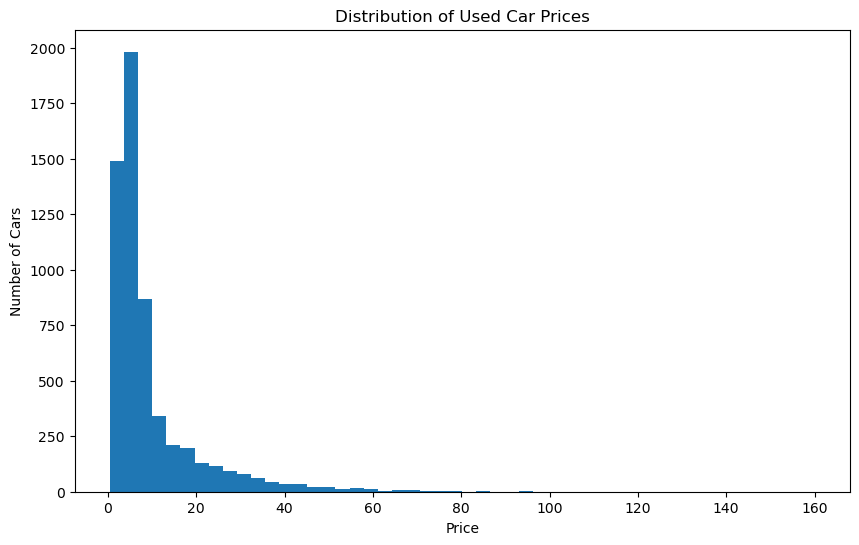

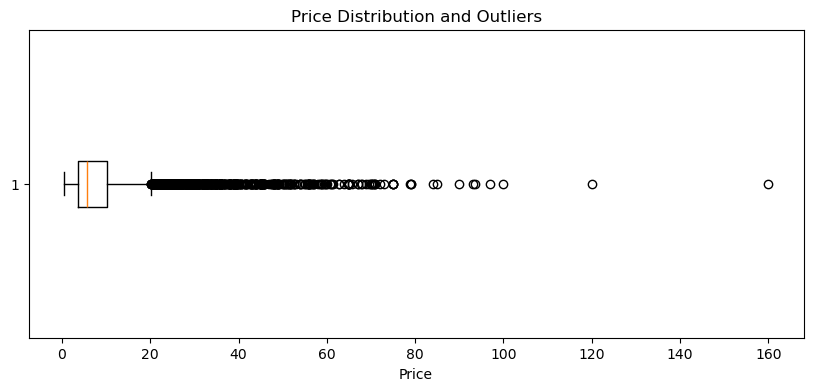

In [11]:
# TARGET & NUMERICAL ANALYSIS

numerical_cols = [
    "Year",
    "Kilometers_Driven",
    "Mileage",
    "Engine",
    "Power",
    "Seats",
    "Price"
]

# Statistical summary

print("=" * 60)
print("NUMERICAL SUMMARY")
print("=" * 60)

print(df_clean[numerical_cols].describe().T)


# Target variable summary

print("\n" + "=" * 60)
print("PRICE SUMMARY")
print("=" * 60)

print("Minimum Price :", df_clean["Price"].min())
print("Maximum Price :", df_clean["Price"].max())
print("Mean Price    :", df_clean["Price"].mean())
print("Median Price  :", df_clean["Price"].median())


# Price distribution

plt.figure(figsize=(10, 6))

plt.hist(df_clean["Price"], bins=50)

plt.title("Distribution of Used Car Prices")
plt.xlabel("Price")
plt.ylabel("Number of Cars")

plt.show()


# Boxplot for Price

plt.figure(figsize=(10, 4))

plt.boxplot(df_clean["Price"], vert=False)

plt.title("Price Distribution and Outliers")
plt.xlabel("Price")

plt.show()

CORRELATION WITH PRICE
Price                1.000000
Power                0.772422
Engine               0.656887
Year                 0.300675
Seats                0.053251
Kilometers_Driven   -0.008330
Mileage             -0.340406
Name: Price, dtype: float64


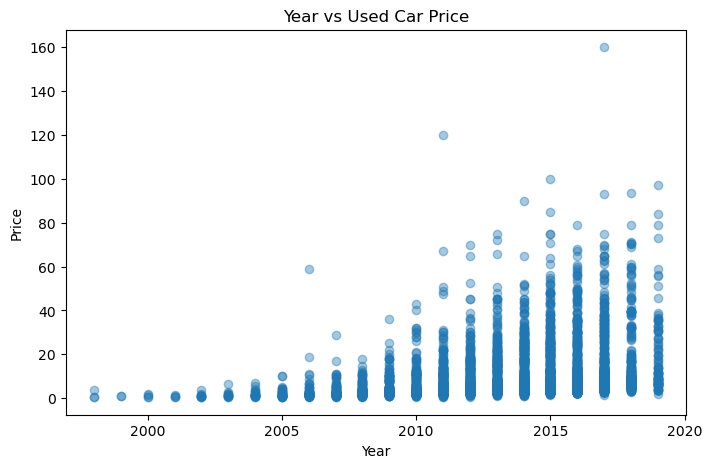

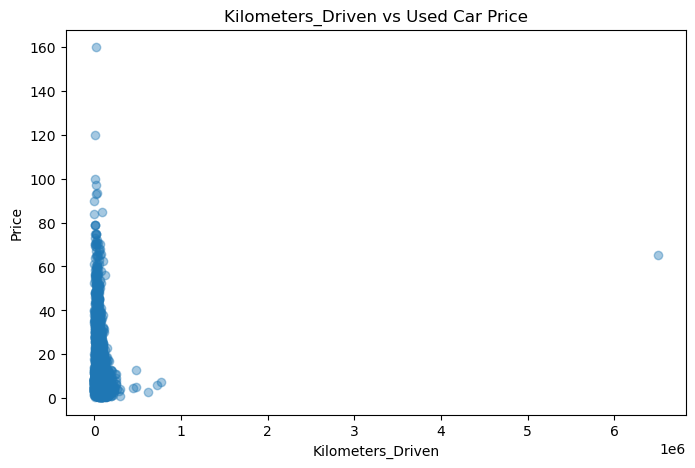

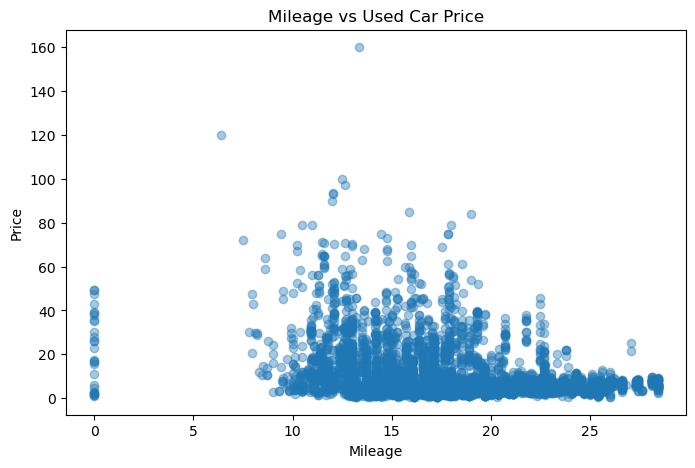

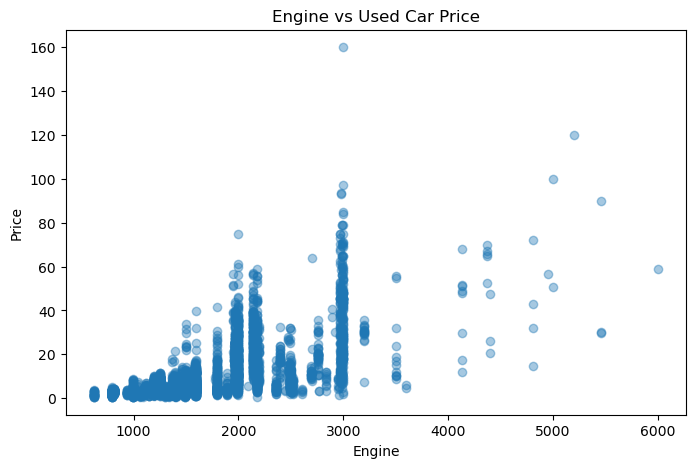

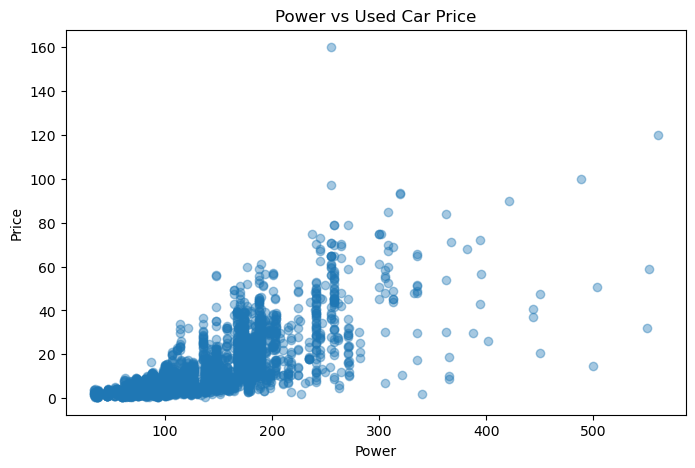

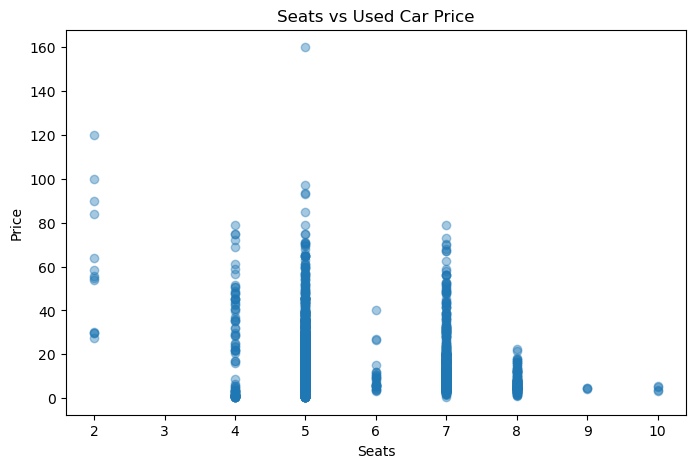

In [12]:
# NUMERICAL FEATURES vs PRICE

features = [
    "Year",
    "Kilometers_Driven",
    "Mileage",
    "Engine",
    "Power",
    "Seats"
]

# Correlation with Price

correlation = df_clean[features + ["Price"]].corr()["Price"].sort_values(
    ascending=False
)

print("=" * 60)
print("CORRELATION WITH PRICE")
print("=" * 60)

print(correlation)


# Scatter plots

for feature in features:

    plt.figure(figsize=(8, 5))

    plt.scatter(
        df_clean[feature],
        df_clean["Price"],
        alpha=0.4
    )

    plt.title(f"{feature} vs Used Car Price")
    plt.xlabel(feature)
    plt.ylabel("Price")

    plt.show()


FUEL_TYPE vs PRICE
           count       mean  median   min    max
Fuel_Type                                       
Diesel      3152  12.958496    7.84  0.60  160.0
Petrol      2655   5.773416    4.25  0.44  120.0

TRANSMISSION vs PRICE
              count       mean  median   min     max
Transmission                                        
Automatic      1702  19.914918    16.0  1.50  160.00
Manual         4105   5.427140     4.7  0.44   35.82

OWNER_TYPE vs PRICE
                count       mean  median   min    max
Owner_Type                                           
First            4786  10.122900    6.00  0.50  160.0
Second            913   7.847952    4.50  0.44   90.0
Fourth & Above      7   3.567143    3.25  1.97    5.5
Third             101   5.299505    2.95  0.45  120.0


C:\Users\gayat\AppData\Local\Temp\ipykernel_17980\1600645814.py:39: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  plt.boxplot(data, labels=categories)


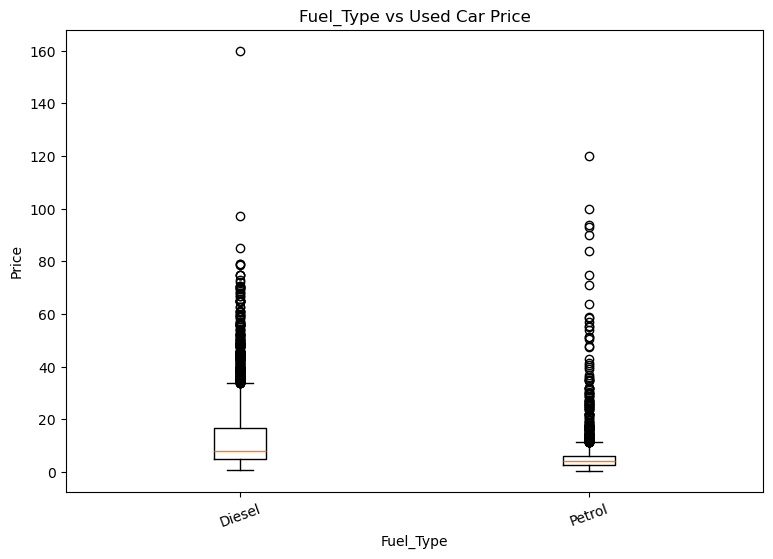

C:\Users\gayat\AppData\Local\Temp\ipykernel_17980\1600645814.py:39: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  plt.boxplot(data, labels=categories)


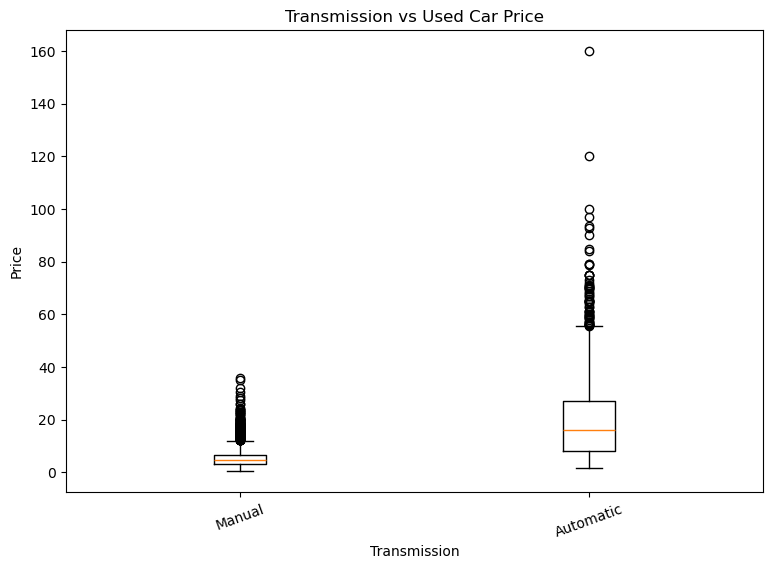

C:\Users\gayat\AppData\Local\Temp\ipykernel_17980\1600645814.py:39: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  plt.boxplot(data, labels=categories)


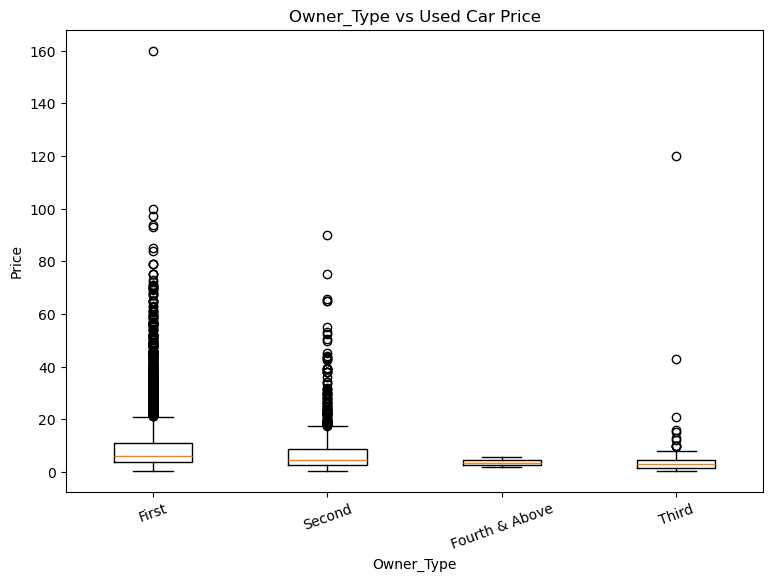

In [13]:
# CATEGORICAL FEATURES vs PRICE

categorical_features = [
    "Fuel_Type",
    "Transmission",
    "Owner_Type"
]

# Price statistics by category

for feature in categorical_features:

    print("\n" + "=" * 60)
    print(f"{feature.upper()} vs PRICE")
    print("=" * 60)

    summary = (
        df_clean.groupby(feature)["Price"]
        .agg(["count", "mean", "median", "min", "max"])
        .sort_values("median", ascending=False)
    )

    print(summary)


# Boxplots

for feature in categorical_features:

    plt.figure(figsize=(9, 6))

    categories = df_clean[feature].dropna().unique()

    data = [
        df_clean.loc[df_clean[feature] == category, "Price"]
        for category in categories
    ]

    plt.boxplot(data, labels=categories)

    plt.title(f"{feature} vs Used Car Price")
    plt.xlabel(feature)
    plt.ylabel("Price")

    plt.xticks(rotation=20)

    plt.show()

In [14]:
# BRAND EXTRACTION

df_clean["Brand"] = df_clean["Name"].str.split().str[0]

print("Unique brands:")
print(sorted(df_clean["Brand"].unique()))

print("\nNumber of unique brands:", df_clean["Brand"].nunique())

Unique brands:
['Ambassador', 'Audi', 'BMW', 'Bentley', 'Chevrolet', 'Datsun', 'Fiat', 'Force', 'Ford', 'Honda', 'Hyundai', 'ISUZU', 'Isuzu', 'Jaguar', 'Jeep', 'Lamborghini', 'Land', 'Mahindra', 'Maruti', 'Mercedes-Benz', 'Mini', 'Mitsubishi', 'Nissan', 'Porsche', 'Renault', 'Skoda', 'Tata', 'Toyota', 'Volkswagen', 'Volvo']

Number of unique brands: 30


In [15]:
# BRAND DISTRIBUTION

brand_counts = df_clean["Brand"].value_counts()

print(brand_counts)

Brand
Maruti           1121
Hyundai          1050
Honda             600
Toyota            393
Mercedes-Benz     316
Volkswagen        314
Ford              294
Mahindra          268
BMW               262
Audi              235
Tata              181
Skoda             172
Renault           145
Chevrolet         120
Nissan             89
Land               57
Jaguar             40
Mitsubishi         27
Mini               26
Fiat               23
Volvo              21
Porsche            16
Jeep               15
Datsun             13
Force               3
ISUZU               2
Isuzu               1
Ambassador          1
Bentley             1
Lamborghini         1
Name: count, dtype: int64


In [16]:
# BRAND vs PRICE

brand_price = (
    df_clean.groupby("Brand")["Price"]
    .agg(["count", "mean", "median", "min", "max"])
    .sort_values("median", ascending=False)
)

print(brand_price)

               count        mean   median     min     max
Brand                                                    
Lamborghini        1  120.000000  120.000  120.00  120.00
Bentley            1   59.000000   59.000   59.00   59.00
Porsche           16   49.204375   49.360    2.02   75.00
Land              57   39.861053   35.000   11.00  160.00
Jaguar            40   37.632250   31.900   16.00  100.00
Mini              26   26.896923   24.285   17.00   39.75
Mercedes-Benz    316   26.917848   24.230    3.90   90.00
Audi             235   25.569787   23.500    7.50   72.94
BMW              262   25.439618   21.415    6.30   93.67
Isuzu              1   20.000000   20.000   20.00   20.00
Jeep              15   18.718667   18.500   15.00   23.91
Volvo             21   18.802857   18.250    7.25   32.50
ISUZU              2   12.045000   12.045    8.00   16.09
Toyota           393   11.929746   11.000    1.50   35.82
Mitsubishi        27   11.058889    9.950    1.00   28.00
Force         

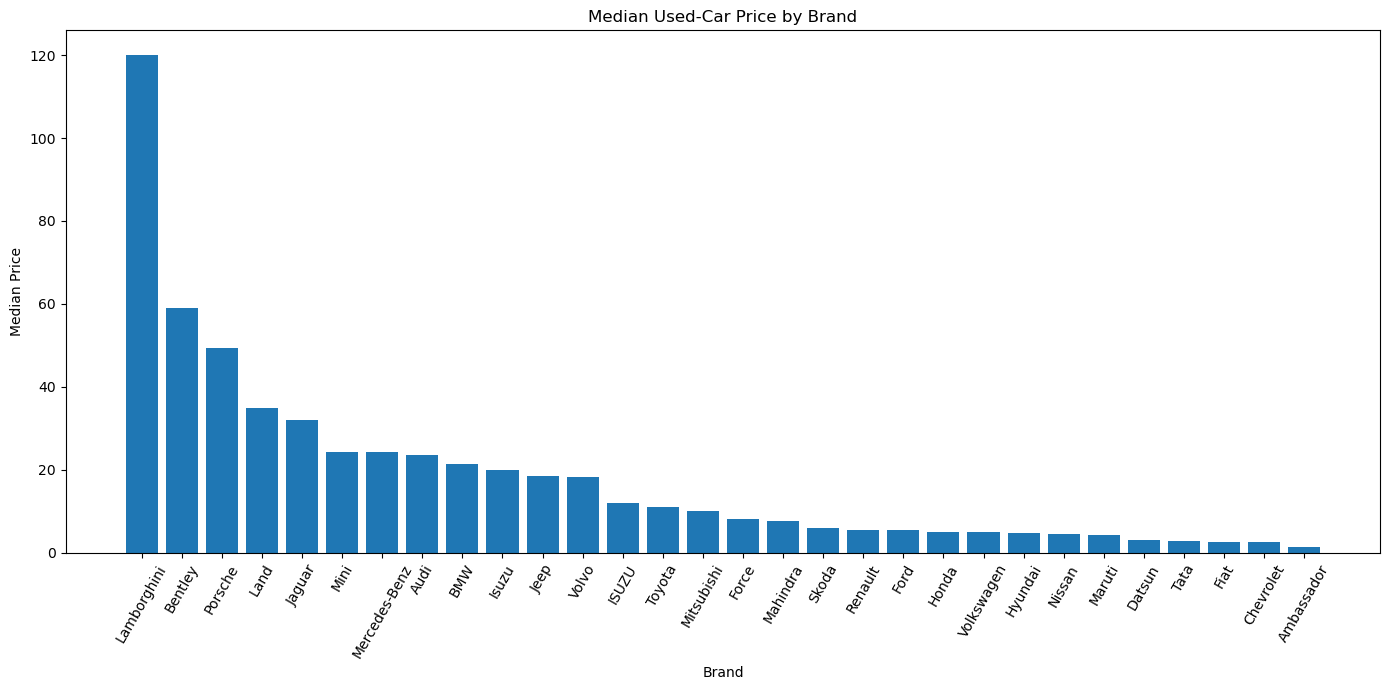

In [17]:
plt.figure(figsize=(14, 7))

brand_median_price = (
    df_clean.groupby("Brand")["Price"]
    .median()
    .sort_values(ascending=False)
)

plt.bar(
    brand_median_price.index,
    brand_median_price.values
)

plt.title("Median Used-Car Price by Brand")
plt.xlabel("Brand")
plt.ylabel("Median Price")

plt.xticks(rotation=60)

plt.tight_layout()
plt.show()

In [18]:
sorted(df_clean["Brand"].unique())

['Ambassador',
 'Audi',
 'BMW',
 'Bentley',
 'Chevrolet',
 'Datsun',
 'Fiat',
 'Force',
 'Ford',
 'Honda',
 'Hyundai',
 'ISUZU',
 'Isuzu',
 'Jaguar',
 'Jeep',
 'Lamborghini',
 'Land',
 'Mahindra',
 'Maruti',
 'Mercedes-Benz',
 'Mini',
 'Mitsubishi',
 'Nissan',
 'Porsche',
 'Renault',
 'Skoda',
 'Tata',
 'Toyota',
 'Volkswagen',
 'Volvo']

In [19]:
print("Minimum year:", df_clean["Year"].min())
print("Maximum year:", df_clean["Year"].max())

print("\nYear distribution:")
print(df_clean["Year"].value_counts().sort_index())

Minimum year: 1998
Maximum year: 2019

Year distribution:
Year
1998      3
1999      2
2000      4
2001      4
2002     11
2003     14
2004     25
2005     42
2006     66
2007    104
2008    160
2009    191
2010    328
2011    450
2012    551
2013    630
2014    782
2015    731
2016    733
2017    581
2018    294
2019    101
Name: count, dtype: int64


In [20]:
reference_year = df_clean["Year"].max()

df_clean["Car_Age"] = reference_year - df_clean["Year"]

print("Reference year:", reference_year)

print("\nCar age summary:")
print(df_clean["Car_Age"].describe())

Reference year: 2019

Car age summary:
count    5807.000000
mean        5.524195
std         3.170718
min         0.000000
25%         3.000000
50%         5.000000
75%         7.000000
max        21.000000
Name: Car_Age, dtype: float64


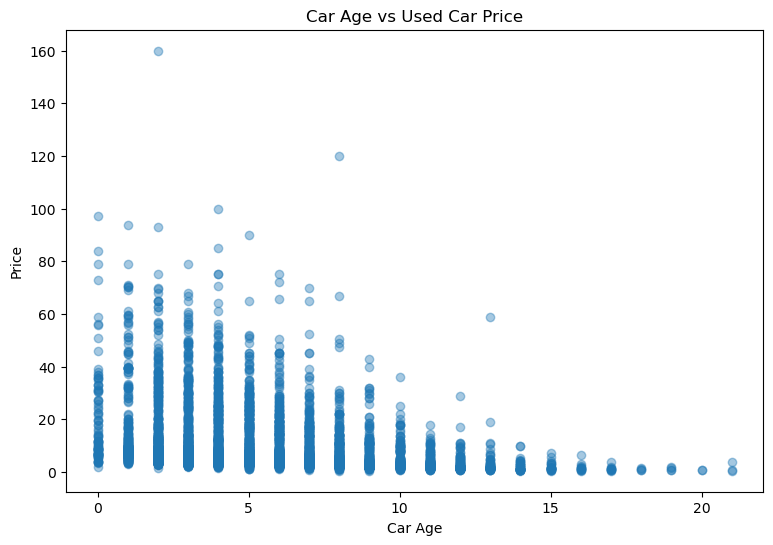

In [21]:
plt.figure(figsize=(9, 6))

plt.scatter(
    df_clean["Car_Age"],
    df_clean["Price"],
    alpha=0.4
)

plt.title("Car Age vs Used Car Price")
plt.xlabel("Car Age")
plt.ylabel("Price")

plt.show()

In [22]:
age_price = (
    df_clean.groupby("Car_Age")["Price"]
    .agg(["count", "mean", "median"])
)

print(age_price)

         count       mean  median
Car_Age                          
0          101  19.603564  11.540
1          294  15.884558   8.875
2          581  13.848778   8.200
3          733  11.775130   7.000
4          731  11.344118   6.250
5          782   9.739079   5.750
6          630   8.830794   5.130
7          551   7.448657   4.500
8          450   6.833933   3.850
9          328   5.500396   3.000
10         191   5.276073   3.110
11         160   3.640437   2.600
12         104   3.448558   2.000
13          66   3.673485   1.800
14          42   2.290952   1.350
15          25   2.012000   1.400
16          14   1.697857   1.300
17          11   1.273636   1.000
18           4   0.975000   0.875
19           4   1.175000   1.100
20           2   0.835000   0.835
21           3   1.626667   0.530


In [23]:
# LOCATION ANALYSIS

# Number of cars in each location
location_counts = df_clean["Location"].value_counts()

print("=" * 60)
print("NUMBER OF CARS BY LOCATION")
print("=" * 60)

print(location_counts)


# Location vs Price

location_price = (
    df_clean.groupby("Location")["Price"]
    .agg(["count", "mean", "median", "min", "max"])
    .sort_values("median", ascending=False)
)

print("\n" + "=" * 60)
print("LOCATION vs PRICE")
print("=" * 60)

print(location_price)

NUMBER OF CARS BY LOCATION
Location
Mumbai        757
Hyderabad     709
Kochi         637
Coimbatore    629
Pune          581
Delhi         535
Kolkata       521
Chennai       474
Jaipur        400
Bangalore     347
Ahmedabad     217
Name: count, dtype: int64

LOCATION vs PRICE
            count       mean  median   min     max
Location                                          
Coimbatore    629  15.140350   8.360  1.68   93.67
Bangalore     347  13.638040   7.200  1.65   93.00
Kochi         637  11.323940   6.820  1.26   97.07
Ahmedabad     217   8.593134   6.000  0.75   85.00
Hyderabad     709  10.003343   5.990  0.60  160.00
Mumbai        757   9.566592   5.900  0.55   75.00
Delhi         535   9.905514   5.700  0.75  120.00
Chennai       474   7.960802   4.725  0.70   70.00
Pune          581   6.992324   4.500  0.44   68.00
Jaipur        400   5.949225   4.275  0.45   42.50
Kolkata       521   5.739885   3.750  0.65   75.00


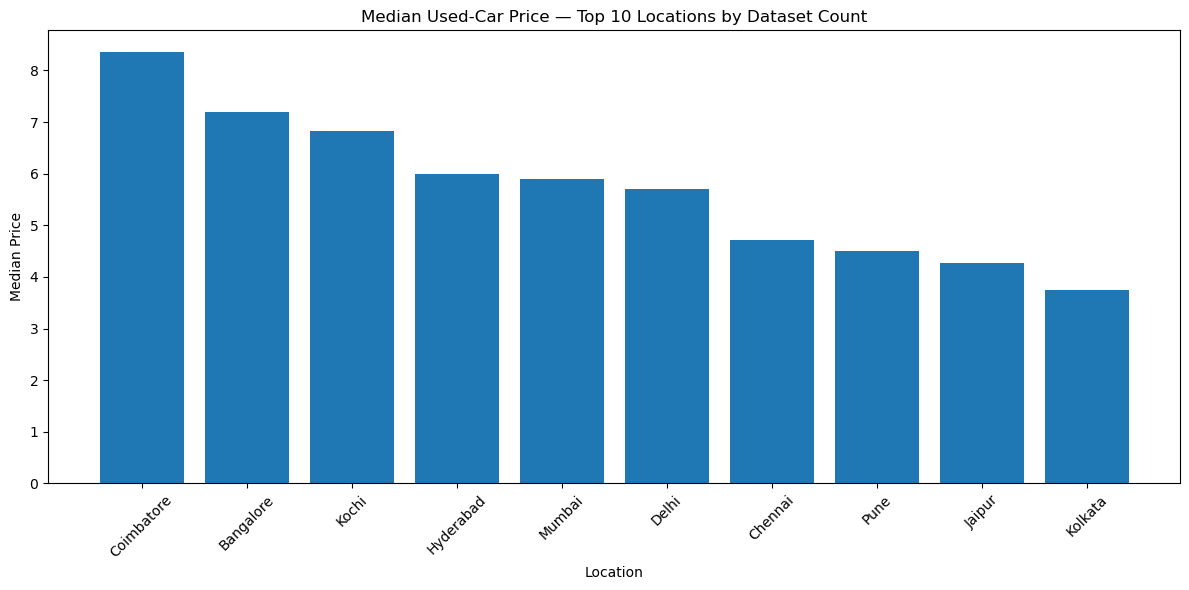

In [24]:
# TOP 10 LOCATIONS BY NUMBER OF CARS

top_locations = df_clean["Location"].value_counts().head(10).index

location_median_price = (
    df_clean[df_clean["Location"].isin(top_locations)]
    .groupby("Location")["Price"]
    .median()
    .sort_values(ascending=False)
)

plt.figure(figsize=(12, 6))

plt.bar(
    location_median_price.index,
    location_median_price.values
)

plt.title("Median Used-Car Price — Top 10 Locations by Dataset Count")
plt.xlabel("Location")
plt.ylabel("Median Price")

plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

In [25]:
# FINAL FEATURE ENGINEERING

# Creating a modelling dataframe
model_df = df_clean.copy()

# Removing the raw Name column
model_df.drop(columns=["Name"], inplace=True)

# Displaying the resulting dataset
print("Shape:", model_df.shape)

print("\nColumns:")
print(model_df.columns.tolist())

print("\nData types:")
print(model_df.dtypes)

print("\nFirst 5 rows:")
print(model_df.head())

Shape: (5807, 13)

Columns:
['Location', 'Year', 'Kilometers_Driven', 'Fuel_Type', 'Transmission', 'Owner_Type', 'Mileage', 'Engine', 'Power', 'Seats', 'Price', 'Brand', 'Car_Age']

Data types:
Location              object
Year                   int64
Kilometers_Driven      int64
Fuel_Type             object
Transmission          object
Owner_Type            object
Mileage              float64
Engine               float64
Power                float64
Seats                float64
Price                float64
Brand                 object
Car_Age                int64
dtype: object

First 5 rows:
     Location  Year  Kilometers_Driven Fuel_Type Transmission Owner_Type  \
0        Pune  2015              41000    Diesel       Manual      First   
1     Chennai  2011              46000    Petrol       Manual      First   
2     Chennai  2012              87000    Diesel       Manual      First   
3  Coimbatore  2013              40670    Diesel    Automatic     Second   
4      Jaipur  2013 

In [26]:
# CHECKING CATEGORICAL FEATURES

categorical_cols = model_df.select_dtypes(
    include="object"
).columns.tolist()

numerical_cols = model_df.select_dtypes(
    include=["int64", "float64"]
).columns.tolist()

print("Categorical columns:")
print(categorical_cols)

print("\nNumerical columns:")
print(numerical_cols)

Categorical columns:
['Location', 'Fuel_Type', 'Transmission', 'Owner_Type', 'Brand']

Numerical columns:
['Year', 'Kilometers_Driven', 'Mileage', 'Engine', 'Power', 'Seats', 'Price', 'Car_Age']


In [27]:
# TRAIN / TEST SPLIT

# Target
X = model_df.drop(columns=["Price"])
y = model_df["Price"]

print("Feature shape:", X.shape)
print("Target shape:", y.shape)

# 80% training, 20% testing
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42
)

print("\nTraining set:")
print("X_train:", X_train.shape)
print("y_train:", y_train.shape)

print("\nTesting set:")
print("X_test:", X_test.shape)
print("y_test:", y_test.shape)

Feature shape: (5807, 12)
Target shape: (5807,)

Training set:
X_train: (4645, 12)
y_train: (4645,)

Testing set:
X_test: (1162, 12)
y_test: (1162,)


In [28]:
# PREPROCESSING PIPELINE

from sklearn.compose import ColumnTransformer

# Identify columns
categorical_cols = X.select_dtypes(
    include=["object"]
).columns.tolist()

numerical_cols = X.select_dtypes(
    include=["int64", "float64"]
).columns.tolist()

print("Categorical columns:")
print(categorical_cols)

print("\nNumerical columns:")
print(numerical_cols)


# Numerical preprocessing
numeric_transformer = StandardScaler()


# Categorical preprocessing
categorical_transformer = OneHotEncoder(
    handle_unknown="ignore",
    sparse_output=False
)


# Combine preprocessing
preprocessor = ColumnTransformer(
    transformers=[
        ("num", numeric_transformer, numerical_cols),
        ("cat", categorical_transformer, categorical_cols)
    ]
)

print("\nPreprocessor created successfully.")

Categorical columns:
['Location', 'Fuel_Type', 'Transmission', 'Owner_Type', 'Brand']

Numerical columns:
['Year', 'Kilometers_Driven', 'Mileage', 'Engine', 'Power', 'Seats', 'Car_Age']

Preprocessor created successfully.


In [29]:
handle_unknown="ignore"

In [30]:
# BASELINE REGRESSION MODELS

from sklearn.linear_model import Ridge
from sklearn.ensemble import RandomForestRegressor

# Defining models

models = {
    "Linear Regression": LinearRegression(),

    "Ridge Regression": Ridge(
        alpha=1.0
    ),

    "Random Forest": RandomForestRegressor(
        n_estimators=300,
        random_state=42,
        n_jobs=-1
    ),

    "Gradient Boosting": GradientBoostingRegressor(
        n_estimators=200,
        learning_rate=0.05,
        max_depth=3,
        random_state=42
    )
}


# Train and evaluate

results = []

trained_models = {}

for name, model in models.items():

    print(f"\nTraining {name}...")

    pipeline = Pipeline(
        steps=[
            ("preprocessor", preprocessor),
            ("model", model)
        ]
    )

    # Train
    pipeline.fit(X_train, y_train)

    # Predict
    y_pred = pipeline.predict(X_test)

    # Metrics
    mae = mean_absolute_error(y_test, y_pred)

    rmse = np.sqrt(
        mean_squared_error(y_test, y_pred)
    )

    r2 = r2_score(y_test, y_pred)

    results.append({
        "Model": name,
        "MAE": mae,
        "RMSE": rmse,
        "R2": r2
    })

    trained_models[name] = pipeline

    print("MAE :", round(mae, 4))
    print("RMSE:", round(rmse, 4))
    print("R²  :", round(r2, 4))

# Comparison table

results_df = pd.DataFrame(results)

results_df = results_df.sort_values(
    by="RMSE",
    ascending=True
).reset_index(drop=True)

print("\n" + "=" * 70)
print("BASELINE MODEL COMPARISON")
print("=" * 70)

print(results_df)


Training Linear Regression...
MAE : 2.9341
RMSE: 5.1071
R²  : 0.7692

Training Ridge Regression...
MAE : 2.9491
RMSE: 5.1072
R²  : 0.7692

Training Random Forest...
MAE : 1.4903
RMSE: 3.7514
R²  : 0.8755

Training Gradient Boosting...
MAE : 1.8135
RMSE: 4.0591
R²  : 0.8542

BASELINE MODEL COMPARISON
               Model       MAE      RMSE        R2
0      Random Forest  1.490266  3.751389  0.875491
1  Gradient Boosting  1.813454  4.059073  0.854229
2  Linear Regression  2.934088  5.107093  0.769238
3   Ridge Regression  2.949104  5.107217  0.769227


In [31]:
# 5-FOLD CROSS-VALIDATION

from sklearn.model_selection import KFold, cross_validate

# Using 5-fold cross-validation
cv = KFold(
    n_splits=5,
    shuffle=True,
    random_state=42
)

cv_results = []

for name, model in models.items():

    pipeline = Pipeline(
        steps=[
            ("preprocessor", preprocessor),
            ("model", model)
        ]
    )

    scores = cross_validate(
        pipeline,
        X_train,
        y_train,
        cv=cv,
        scoring={
            "MAE": "neg_mean_absolute_error",
            "RMSE": "neg_root_mean_squared_error",
            "R2": "r2"
        },
        n_jobs=-1
    )

    mae_scores = -scores["test_MAE"]
    rmse_scores = -scores["test_RMSE"]
    r2_scores = scores["test_R2"]

    cv_results.append({
        "Model": name,
        "Mean MAE": mae_scores.mean(),
        "Std MAE": mae_scores.std(),
        "Mean RMSE": rmse_scores.mean(),
        "Std RMSE": rmse_scores.std(),
        "Mean R2": r2_scores.mean(),
        "Std R2": r2_scores.std()
    })

cv_results_df = pd.DataFrame(cv_results)

print("=" * 90)
print("5-FOLD CROSS-VALIDATION RESULTS")
print("=" * 90)

print(
    cv_results_df
    .sort_values("Mean RMSE")
    .reset_index(drop=True)
)

5-FOLD CROSS-VALIDATION RESULTS
               Model  Mean MAE   Std MAE  Mean RMSE  Std RMSE   Mean R2  \
0      Random Forest  1.496346  0.078026   3.584819  0.528023  0.899242   
1  Gradient Boosting  1.751939  0.083756   3.751173  0.417146  0.890894   
2  Linear Regression  3.044484  0.056441   5.968977  0.637007  0.719968   
3   Ridge Regression  3.065307  0.048507   5.983396  0.642484  0.718281   

     Std R2  
0  0.029801  
1  0.023572  
2  0.078565  
3  0.080660  


In [32]:
from sklearn.model_selection import RandomizedSearchCV

rf_pipeline = Pipeline([
    ("preprocessor", preprocessor),
    ("model", RandomForestRegressor(
        random_state=42,
        n_jobs=-1
    ))
])

param_distributions = {
    "model__n_estimators": [200, 300, 500, 700],
    "model__max_depth": [None, 10, 15, 20, 25, 30],
    "model__min_samples_split": [2, 5, 10],
    "model__min_samples_leaf": [1, 2, 4],
    "model__max_features": ["sqrt", "log2", 0.7, 1.0]
}

rf_random_search = RandomizedSearchCV(
    estimator=rf_pipeline,
    param_distributions=param_distributions,
    n_iter=25,
    scoring="neg_root_mean_squared_error",
    cv=cv,
    random_state=42,
    n_jobs=-1,
    verbose=1
)

rf_random_search.fit(X_train, y_train)

print("Best Parameters:")
print(rf_random_search.best_params_)

print("\nBest CV RMSE:")
print(-rf_random_search.best_score_)

Fitting 5 folds for each of 25 candidates, totalling 125 fits
Best Parameters:
{'model__n_estimators': 700, 'model__min_samples_split': 10, 'model__min_samples_leaf': 1, 'model__max_features': 0.7, 'model__max_depth': 25}

Best CV RMSE:
3.5996819090218337


In [33]:
# Baseline Random Forest
baseline_rf = trained_models["Random Forest"]

# Tuned Random Forest
tuned_rf = rf_random_search.best_estimator_

# Predictions
baseline_pred = baseline_rf.predict(X_test)
tuned_pred = tuned_rf.predict(X_test)

# Evaluation function
def evaluate_model(y_true, y_pred):
    mae = mean_absolute_error(y_true, y_pred)
    rmse = np.sqrt(mean_squared_error(y_true, y_pred))
    r2 = r2_score(y_true, y_pred)

    return mae, rmse, r2

# Evaluate baseline
baseline_mae, baseline_rmse, baseline_r2 = evaluate_model(
    y_test,
    baseline_pred
)

# Evaluate tuned model
tuned_mae, tuned_rmse, tuned_r2 = evaluate_model(
    y_test,
    tuned_pred
)

# Comparison table
final_comparison = pd.DataFrame({
    "Model": [
        "Baseline Random Forest",
        "Tuned Random Forest"
    ],
    "MAE": [
        baseline_mae,
        tuned_mae
    ],
    "RMSE": [
        baseline_rmse,
        tuned_rmse
    ],
    "R2": [
        baseline_r2,
        tuned_r2
    ]
})

print("=" * 80)
print("FINAL TEST-SET MODEL COMPARISON")
print("=" * 80)

print(
    final_comparison
    .round(4)
    .to_string(index=False)
)

FINAL TEST-SET MODEL COMPARISON
                 Model    MAE   RMSE     R2
Baseline Random Forest 1.4903 3.7514 0.8755
   Tuned Random Forest 1.5524 3.7545 0.8753


In [34]:
# Creating error analysis dataframe

error_df = X_test.copy()

error_df["Actual_Price"] = y_test.values
error_df["Predicted_Price"] = baseline_pred
error_df["Absolute_Error"] = (
    error_df["Actual_Price"] - error_df["Predicted_Price"]
).abs()

error_df["Percentage_Error"] = (
    error_df["Absolute_Error"]
    / error_df["Actual_Price"]
) * 100

# Adding useful descriptive columns
error_df["Brand"] = error_df["Brand"].values
error_df["Fuel_Type"] = error_df["Fuel_Type"].values
error_df["Transmission"] = error_df["Transmission"].values
error_df["Location"] = error_df["Location"].values

print("=" * 80)
print("ERROR ANALYSIS")
print("=" * 80)

print("\nAverage Absolute Error:")
print(round(error_df["Absolute_Error"].mean(), 4))

print("\nMedian Absolute Error:")
print(round(error_df["Absolute_Error"].median(), 4))

print("\nAverage Percentage Error:")
print(round(error_df["Percentage_Error"].mean(), 2), "%")

ERROR ANALYSIS

Average Absolute Error:
1.4903

Median Absolute Error:
0.5504

Average Percentage Error:
18.77 %


In [35]:
worst_predictions = (
    error_df
    .sort_values("Absolute_Error", ascending=False)
    [
        [
            "Brand",
            "Location",
            "Fuel_Type",
            "Transmission",
            "Year",
            "Car_Age",
            "Actual_Price",
            "Predicted_Price",
            "Absolute_Error",
            "Percentage_Error"
        ]
    ]
    .head(10)
)

print("\nTOP 10 LARGEST PREDICTION ERRORS")
print("=" * 80)

print(worst_predictions.round(2).to_string(index=False))


TOP 10 LARGEST PREDICTION ERRORS
     Brand   Location Fuel_Type Transmission  Year  Car_Age  Actual_Price  Predicted_Price  Absolute_Error  Percentage_Error
   Porsche      Kochi    Petrol    Automatic  2019        0          2.02            70.30           68.28           3380.44
    Jaguar     Mumbai    Petrol    Automatic  2017        2         34.50            69.85           35.35            102.46
       BMW Coimbatore    Petrol    Automatic  2018        1         93.67            60.48           33.19             35.43
      Audi     Mumbai    Diesel    Automatic  2015        4         32.95            57.57           24.62             74.72
     Skoda  Hyderabad    Petrol    Automatic  2010        9          6.00            29.06           23.06            384.26
     Skoda  Hyderabad    Petrol    Automatic  2009       10          4.75            27.57           22.82            480.34
      Land      Kochi    Diesel    Automatic  2018        1         59.72            37.80 

In [36]:
# Recovering the original car names for the test-set rows
error_analysis = X_test.copy()

error_analysis["Actual_Price"] = y_test.values
error_analysis["Predicted_Price"] = baseline_pred

error_analysis["Absolute_Error"] = (
    error_analysis["Actual_Price"]
    - error_analysis["Predicted_Price"]
).abs()

# Getting original names from df_clean using the same test indices
error_analysis["Name"] = df_clean.loc[
    X_test.index, "Name"
].values

worst_with_names = (
    error_analysis
    .sort_values("Absolute_Error", ascending=False)
    [
        [
            "Name",
            "Brand",
            "Location",
            "Fuel_Type",
            "Transmission",
            "Year",
            "Kilometers_Driven",
            "Mileage",
            "Engine",
            "Power",
            "Seats",
            "Actual_Price",
            "Predicted_Price",
            "Absolute_Error"
        ]
    ]
    .head(15)
)

print("=" * 120)
print("TOP 15 ERRORS WITH ORIGINAL CAR MODEL")
print("=" * 120)

print(worst_with_names.round(2).to_string(index=False))

TOP 15 ERRORS WITH ORIGINAL CAR MODEL
                                             Name         Brand   Location Fuel_Type Transmission  Year  Kilometers_Driven  Mileage  Engine  Power  Seats  Actual_Price  Predicted_Price  Absolute_Error
                             Porsche Cayenne Base       Porsche      Kochi    Petrol    Automatic  2019              14298    13.33  2995.0 340.00    5.0          2.02            70.30           68.28
                              Jaguar XE Portfolio        Jaguar     Mumbai    Petrol    Automatic  2017               9000    13.50  1999.0 246.74    5.0         34.50            69.85           35.35
                               BMW 7 Series 740Li           BMW Coimbatore    Petrol    Automatic  2018              28060    12.05  2979.0 320.00    5.0         93.67            60.48           33.19
               Audi Q5 3.0 TDI Quattro Technology          Audi     Mumbai    Diesel    Automatic  2015              11964    13.22  2967.0 241.40    5.0     

In [37]:
# Creating a new modelling dataframe with Car_Model

model_df_v2 = df_clean.copy()

# Removing target and raw Name only later
# Extracting brand
model_df_v2["Brand"] = (
    model_df_v2["Name"]
    .str.split()
    .str[0]
)

# Extracting a simplified car model
model_df_v2["Car_Model"] = (
    model_df_v2["Name"]
    .str.split()
    .str[1:3]
    .str.join(" ")
)

print(model_df_v2[["Name", "Brand", "Car_Model"]].head(20))

                                                Name          Brand  \
0                   Hyundai Creta 1.6 CRDi SX Option        Hyundai   
1                                       Honda Jazz V          Honda   
2                                  Maruti Ertiga VDI         Maruti   
3                    Audi A4 New 2.0 TDI Multitronic           Audi   
4                             Nissan Micra Diesel XV         Nissan   
5                  Toyota Innova Crysta 2.8 GX AT 8S         Toyota   
6                Volkswagen Vento Diesel Comfortline     Volkswagen   
7                     Tata Indica Vista Quadrajet LS           Tata   
8                                   Maruti Ciaz Zeta         Maruti   
9                        Honda City 1.5 V AT Sunroof          Honda   
10                             Maruti Swift VDI BSIV         Maruti   
11                  Land Rover Range Rover 2.2L Pure           Land   
12                    Land Rover Freelander 2 TD4 SE           Land   
13    

In [38]:
print("\nNumber of unique Car_Model values:")
print(model_df_v2["Car_Model"].nunique())

print("\nSample Car_Model values:")
print(
    model_df_v2["Car_Model"]
    .value_counts()
    .head(30)
)


Number of unique Car_Model values:
655

Sample Car_Model values:
Car_Model
Swift Dzire      152
Grand i10        152
Wagon R          125
Innova 2.5       114
Verna 1.6        110
City i           100
3 Series          98
City 1.5          95
New C-Class       94
Creta 1.6         87
Swift VDI         67
i10 Sportz        65
XUV500 W8         64
i20 1.2           64
5 Series          63
Amaze S           58
i10 Magna         56
Figo Diesel       53
Corolla Altis     51
Ecosport 1.5      48
A4 2.0            48
i20 Asta          47
i20 Sportz        47
Alto 800          47
Innova Crysta     46
Duster 110PS      45
Alto K10          43
Fortuner 4x2      43
Vitara Brezza     43
Polo Petrol       40
Name: count, dtype: int64


In [39]:
# Preparing dataset with Car_Model

model_df_v2 = df_clean.copy()

model_df_v2["Brand"] = (
    model_df_v2["Name"]
    .str.split()
    .str[0]
)

model_df_v2["Car_Model"] = (
    model_df_v2["Name"]
    .str.split()
    .str[1:3]
    .str.join(" ")
)

# Removing raw Name
model_df_v2.drop(columns=["Name"], inplace=True)


# Separating features and target

X_v2 = model_df_v2.drop(columns=["Price"])
y_v2 = model_df_v2["Price"]


# Using the SAME train/test split

X_train_v2, X_test_v2, y_train_v2, y_test_v2 = train_test_split(
    X_v2,
    y_v2,
    test_size=0.20,
    random_state=42
)


# Identifying feature types

categorical_cols_v2 = X_v2.select_dtypes(
    include=["object"]
).columns.tolist()

numerical_cols_v2 = X_v2.select_dtypes(
    include=["int64", "float64"]
).columns.tolist()


print("Categorical columns:")
print(categorical_cols_v2)

print("\nNumerical columns:")
print(numerical_cols_v2)


# Building preprocessing pipeline

preprocessor_v2 = ColumnTransformer(
    transformers=[
        (
            "num",
            StandardScaler(),
            numerical_cols_v2
        ),
        (
            "cat",
            OneHotEncoder(
                handle_unknown="ignore",
                sparse_output=False
            ),
            categorical_cols_v2
        )
    ]
)


# Random Forest with Car_Model

rf_v2 = Pipeline([
    (
        "preprocessor",
        preprocessor_v2
    ),
    (
        "model",
        RandomForestRegressor(
            n_estimators=300,
            random_state=42,
            n_jobs=-1
        )
    )
])


# Train

print("\nTraining Random Forest with Car_Model...")

rf_v2.fit(
    X_train_v2,
    y_train_v2
)


# Test predictions

y_pred_v2 = rf_v2.predict(X_test_v2)


# Evaluate

mae_v2 = mean_absolute_error(
    y_test_v2,
    y_pred_v2
)

rmse_v2 = np.sqrt(
    mean_squared_error(
        y_test_v2,
        y_pred_v2
    )
)

r2_v2 = r2_score(
    y_test_v2,
    y_pred_v2
)


# Comparing against baseline

comparison_v2 = pd.DataFrame({
    "Model": [
        "Baseline Random Forest",
        "Random Forest + Car_Model"
    ],
    "MAE": [
        baseline_mae,
        mae_v2
    ],
    "RMSE": [
        baseline_rmse,
        rmse_v2
    ],
    "R2": [
        baseline_r2,
        r2_v2
    ]
})


print("\n" + "=" * 80)
print("CAR_MODEL FEATURE EXPERIMENT")
print("=" * 80)

print(
    comparison_v2
    .round(4)
    .to_string(index=False)
)

Categorical columns:
['Location', 'Fuel_Type', 'Transmission', 'Owner_Type', 'Brand', 'Car_Model']

Numerical columns:
['Year', 'Kilometers_Driven', 'Mileage', 'Engine', 'Power', 'Seats', 'Car_Age']

Training Random Forest with Car_Model...

CAR_MODEL FEATURE EXPERIMENT
                    Model    MAE   RMSE     R2
   Baseline Random Forest 1.4903 3.7514 0.8755
Random Forest + Car_Model 1.4163 3.5744 0.8870


In [40]:
cv_v2 = KFold(
    n_splits=5,
    shuffle=True,
    random_state=42
)

scores_v2 = cross_validate(
    rf_v2,
    X_train_v2,
    y_train_v2,
    cv=cv_v2,
    scoring={
        "MAE": "neg_mean_absolute_error",
        "RMSE": "neg_root_mean_squared_error",
        "R2": "r2"
    },
    n_jobs=-1
)

mae_scores_v2 = -scores_v2["test_MAE"]
rmse_scores_v2 = -scores_v2["test_RMSE"]
r2_scores_v2 = scores_v2["test_R2"]

print("=" * 80)
print("5-FOLD CROSS-VALIDATION — RANDOM FOREST + CAR_MODEL")
print("=" * 80)

print(f"\nMean MAE : {mae_scores_v2.mean():.4f}")
print(f"Std MAE  : {mae_scores_v2.std():.4f}")

print(f"\nMean RMSE: {rmse_scores_v2.mean():.4f}")
print(f"Std RMSE : {rmse_scores_v2.std():.4f}")

print(f"\nMean R²  : {r2_scores_v2.mean():.4f}")
print(f"Std R²   : {r2_scores_v2.std():.4f}")

5-FOLD CROSS-VALIDATION — RANDOM FOREST + CAR_MODEL

Mean MAE : 1.4489
Std MAE  : 0.0676

Mean RMSE: 3.4552
Std RMSE : 0.4995

Mean R²  : 0.9067
Std R²   : 0.0263


In [41]:
# FEATURE IMPORTANCE — RANDOM FOREST + CAR_MODEL

# Getting fitted preprocessing and model
fitted_preprocessor = rf_v2.named_steps["preprocessor"]
fitted_rf = rf_v2.named_steps["model"]

# Getting transformed feature names
feature_names = fitted_preprocessor.get_feature_names_out()

# Getting Random Forest feature importance
importances = fitted_rf.feature_importances_

# Creating dataframe
feature_importance_df = pd.DataFrame({
    "Feature": feature_names,
    "Importance": importances
})

# Sorting by importance
feature_importance_df = (
    feature_importance_df
    .sort_values("Importance", ascending=False)
    .reset_index(drop=True)
)

print("=" * 80)
print("TOP 25 FEATURE IMPORTANCES")
print("=" * 80)

print(
    feature_importance_df
    .head(25)
    .round(4)
    .to_string(index=False)
)

TOP 25 FEATURE IMPORTANCES
                       Feature  Importance
                    num__Power      0.6667
                  num__Car_Age      0.0992
                     num__Year      0.0501
        num__Kilometers_Driven      0.0469
                   num__Engine      0.0303
    cat__Car_Model_Rover Range      0.0137
                  num__Mileage      0.0131
               cat__Brand_Land      0.0083
      cat__Brand_Mercedes-Benz      0.0056
                    num__Seats      0.0049
       cat__Location_Hyderabad      0.0043
               cat__Brand_Mini      0.0028
cat__Car_Model_Rover Discovery      0.0028
      cat__Transmission_Manual      0.0025
               cat__Brand_Audi      0.0022
   cat__Transmission_Automatic      0.0020
      cat__Location_Coimbatore      0.0017
             cat__Brand_Jaguar      0.0016
       cat__Location_Bangalore      0.0014
           cat__Location_Kochi      0.0013
       cat__Car_Model_5 Series      0.0013
          cat__Location_Mum

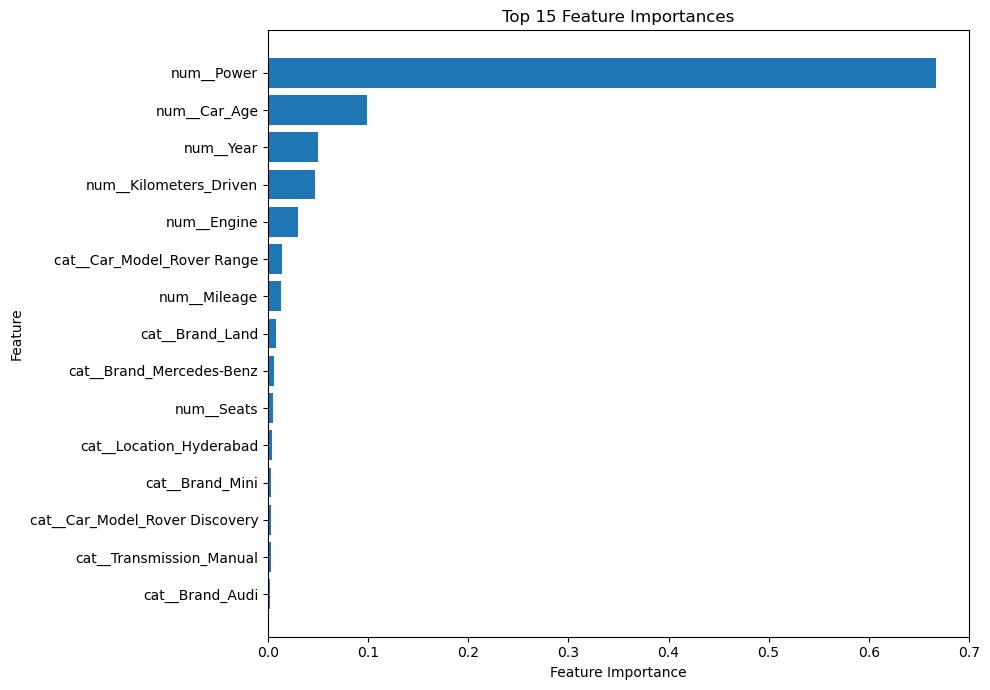

In [42]:
top_features = (
    feature_importance_df
    .head(15)
    .sort_values("Importance")
)

plt.figure(figsize=(10, 7))

plt.barh(
    top_features["Feature"],
    top_features["Importance"]
)

plt.xlabel("Feature Importance")
plt.ylabel("Feature")
plt.title("Top 15 Feature Importances")

plt.tight_layout()

# Save as SVG
plt.savefig(
    "carvista_feature_importance.svg",
    format="svg",
    bbox_inches="tight"
)

plt.show()

In [43]:
# DATA QUALITY / ANOMALY AUDIT

print("=" * 90)
print("CARVISTA DATA QUALITY AUDIT")
print("=" * 90)

# Checking impossible / suspicious numerical values

numeric_checks = {
    "Year <= 0": (df_clean["Year"] <= 0).sum(),
    "Kilometers_Driven < 0": (df_clean["Kilometers_Driven"] < 0).sum(),
    "Mileage <= 0": (df_clean["Mileage"] <= 0).sum(),
    "Engine <= 0": (df_clean["Engine"] <= 0).sum(),
    "Power <= 0": (df_clean["Power"] <= 0).sum(),
    "Seats <= 0": (df_clean["Seats"] <= 0).sum(),
    "Price <= 0": (df_clean["Price"] <= 0).sum()
}

print("\nSuspicious numerical values:")
for check, count in numeric_checks.items():
    print(f"{check:<30}: {count}")


# Checking extreme numerical values using quantiles

numeric_cols_audit = [
    "Year",
    "Kilometers_Driven",
    "Mileage",
    "Engine",
    "Power",
    "Seats",
    "Price",
    "Car_Age"
]

print("\n" + "=" * 90)
print("NUMERICAL QUANTILES")
print("=" * 90)

print(
    df_clean[numeric_cols_audit]
    .quantile([0.01, 0.05, 0.25, 0.50, 0.75, 0.95, 0.99])
    .round(2)
)

# Counting extreme values using IQR

print("\n" + "=" * 90)
print("IQR-BASED OUTLIER COUNTS")
print("=" * 90)

for col in numeric_cols_audit:

    Q1 = df_clean[col].quantile(0.25)
    Q3 = df_clean[col].quantile(0.75)

    IQR = Q3 - Q1

    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR

    outliers = (
        (df_clean[col] < lower_bound) |
        (df_clean[col] > upper_bound)
    ).sum()

    print(
        f"{col:<22}: {outliers:>5} "
        f"(lower={lower_bound:.2f}, upper={upper_bound:.2f})"
    )

CARVISTA DATA QUALITY AUDIT

Suspicious numerical values:
Year <= 0                     : 0
Kilometers_Driven < 0         : 0
Mileage <= 0                  : 28
Engine <= 0                   : 0
Power <= 0                    : 0
Seats <= 0                    : 0
Price <= 0                    : 0

NUMERICAL QUANTILES
        Year  Kilometers_Driven  Mileage   Engine   Power  Seats  Price  \
0.01  2004.0            4000.00     9.52   796.00   46.30    4.0   0.99   
0.05  2008.0           13000.00    11.50   998.00   62.00    5.0   1.80   
0.25  2012.0           33288.00    15.26  1198.00   78.00    5.0   3.59   
0.50  2014.0           52400.00    18.20  1497.00   98.60    5.0   5.75   
0.75  2016.0           72457.50    21.10  1991.00  139.04    5.0  10.25   
0.95  2018.0          120000.00    25.40  2982.00  204.00    7.0  32.70   
0.99  2019.0          170402.32    28.09  2998.88  298.92    8.0  56.48   

      Car_Age  
0.01      0.0  
0.05      1.0  
0.25      3.0  
0.50      5.0  
0

In [44]:
# INSPECT ZERO / INVALID MILEAGE RECORDS

zero_mileage = (
    df_clean[df_clean["Mileage"] <= 0]
    .sort_values("Price")
)

print("=" * 120)
print("RECORDS WITH MILEAGE <= 0")
print("=" * 120)

print(
    zero_mileage[
        [
            "Name",
            "Brand",
            "Location",
            "Fuel_Type",
            "Transmission",
            "Year",
            "Kilometers_Driven",
            "Mileage",
            "Engine",
            "Power",
            "Seats",
            "Price"
        ]
    ].to_string(index=False)
)

print("\nNumber of records:", len(zero_mileage))

RECORDS WITH MILEAGE <= 0
                                       Name         Brand   Location Fuel_Type Transmission  Year  Kilometers_Driven  Mileage  Engine  Power  Seats  Price
                     Hyundai Santro Xing GL       Hyundai    Kolkata    Petrol       Manual  2009              60170      0.0  1086.0  62.00    5.0   1.15
                     Hyundai Santro Xing GL       Hyundai     Mumbai    Petrol       Manual  2008              65000      0.0  1086.0  62.00    5.0   1.39
                     Hyundai Santro Xing GL       Hyundai       Pune    Petrol       Manual  2008              93000      0.0  1086.0  62.00    5.0   1.45
                     Hyundai Santro Xing GL       Hyundai  Bangalore    Petrol       Manual  2008              35268      0.0  1086.0  62.00    5.0   1.88
                     Hyundai Santro Xing GL       Hyundai      Delhi    Petrol       Manual  2012              61449      0.0  1086.0  62.00    5.0   2.15
                     Hyundai Santro Xing GL 

In [45]:
# HANDLE INVALID MILEAGE VALUES

# Working on a fresh copy
df_model_clean = df_clean.copy()

# Converting invalid mileage values (0 or below) to missing
df_model_clean.loc[df_model_clean["Mileage"] <= 0, "Mileage"] = float("nan")

print("Mileage values after treating <= 0 as missing:")
print(df_model_clean["Mileage"].isna().sum())

print("\nTotal records:")
print(len(df_model_clean))

print("\nMileage summary:")
print(df_model_clean["Mileage"].describe())

Mileage values after treating <= 0 as missing:
28

Total records:
5807

Mileage summary:
count    5779.000000
mean       18.292371
std         4.108437
min         6.400000
25%        15.290000
50%        18.200000
75%        21.100000
max        28.400000
Name: Mileage, dtype: float64


In [51]:
# CARVISTA - RANDOM FOREST + CAR_MODEL
# WITH LEAKAGE-SAFE MISSING VALUE IMPUTATION

from sklearn.impute import SimpleImputer

# Preparing modelling dataset

model_df_v3 = df_model_clean.copy()

# Creating Brand
model_df_v3["Brand"] = (
    model_df_v3["Name"]
    .str.split()
    .str[0]
)

# Creating Car_Model
model_df_v3["Car_Model"] = (
    model_df_v3["Name"]
    .str.split()
    .str[1:3]
    .str.join(" ")
)

# Removing original Name
model_df_v3.drop(columns=["Name"], inplace=True)

# Defining features and target

X_v3 = model_df_v3.drop(columns=["Price"])
y_v3 = model_df_v3["Price"]

# Train-test split

X_train_v3, X_test_v3, y_train_v3, y_test_v3 = train_test_split(
    X_v3,
    y_v3,
    test_size=0.20,
    random_state=42
)

# Identifying column types

categorical_cols_v3 = X_v3.select_dtypes(
    include=["object"]
).columns.tolist()

numerical_cols_v3 = X_v3.select_dtypes(
    include=["int64", "float64"]
).columns.tolist()

print("Categorical columns:")
print(categorical_cols_v3)

print("\nNumerical columns:")
print(numerical_cols_v3)

# Numerical preprocessing

numeric_transformer_v3 = Pipeline(
    steps=[
        ("imputer", SimpleImputer(strategy="median")),
        ("scaler", StandardScaler())
    ]
)

# Categorical preprocessing

categorical_transformer_v3 = Pipeline(
    steps=[
        (
            "imputer",
            SimpleImputer(strategy="most_frequent")
        ),
        (
            "onehot",
            OneHotEncoder(
                handle_unknown="ignore",
                sparse_output=False
            )
        )
    ]
)

# Combined preprocessing

preprocessor_v3 = ColumnTransformer(
    transformers=[
        (
            "num",
            numeric_transformer_v3,
            numerical_cols_v3
        ),
        (
            "cat",
            categorical_transformer_v3,
            categorical_cols_v3
        )
    ]
)

# Random Forest model

rf_v3 = RandomForestRegressor(
    n_estimators=300,
    random_state=42,
    n_jobs=-1
)

rf_pipeline_v3 = Pipeline(
    steps=[
        ("preprocessor", preprocessor_v3),
        ("model", rf_v3)
    ]
)

# Train

rf_pipeline_v3.fit(
    X_train_v3,
    y_train_v3
)

# Test-set predictions

y_pred_v3 = rf_pipeline_v3.predict(X_test_v3)

# Evaluation

mae_v3 = mean_absolute_error(y_test_v3, y_pred_v3)

rmse_v3 = np.sqrt(
    mean_squared_error(y_test_v3, y_pred_v3)
)

r2_v3 = r2_score(
    y_test_v3,
    y_pred_v3
)

print("\n" + "=" * 60)
print("CARVISTA - RF + CAR_MODEL + IMPUTATION")
print("=" * 60)

print(f"MAE  : {mae_v3:.4f}")
print(f"RMSE : {rmse_v3:.4f}")
print(f"R²   : {r2_v3:.4f}")

Categorical columns:
['Location', 'Fuel_Type', 'Transmission', 'Owner_Type', 'Brand', 'Car_Model']

Numerical columns:
['Year', 'Kilometers_Driven', 'Mileage', 'Engine', 'Power', 'Seats', 'Car_Age']

CARVISTA - RF + CAR_MODEL + IMPUTATION
MAE  : 1.4089
RMSE : 3.5546
R²   : 0.8882


In [57]:
# ============================================================
# CARVISTA - 5-FOLD CROSS-VALIDATION
# RF + CAR_MODEL + LEAKAGE-SAFE IMPUTATION
# ============================================================

cv_v3 = KFold(
    n_splits=5,
    shuffle=True,
    random_state=42
)

cv_results_v3 = cross_validate(
    rf_pipeline_v3,
    X_v3,
    y_v3,
    cv=cv_v3,
    scoring={
        "MAE": "neg_mean_absolute_error",
        "RMSE": "neg_root_mean_squared_error",
        "R2": "r2"
    },
    n_jobs=-1,
    return_train_score=False
)

cv_mae_v3 = -cv_results_v3["test_MAE"]
cv_rmse_v3 = -cv_results_v3["test_RMSE"]
cv_r2_v3 = cv_results_v3["test_R2"]

print("=" * 70)
print("CARVISTA - 5-FOLD CROSS-VALIDATION")
print("RF + CAR_MODEL + IMPUTATION")
print("=" * 70)

print("\nFold-wise results:")
for i in range(5):
    print(
        f"Fold {i+1}: "
        f"MAE = {cv_mae_v3[i]:.4f}, "
        f"RMSE = {cv_rmse_v3[i]:.4f}, "
        f"R² = {cv_r2_v3[i]:.4f}"
    )

print("\n" + "-" * 70)
print("Mean ± Standard Deviation")
print("-" * 70)

print(
    f"MAE  : {cv_mae_v3.mean():.4f} "
    f"± {cv_mae_v3.std():.4f}"
)

print(
    f"RMSE : {cv_rmse_v3.mean():.4f} "
    f"± {cv_rmse_v3.std():.4f}"
)

print(
    f"R²   : {cv_r2_v3.mean():.4f} "
    f"± {cv_r2_v3.std():.4f}"
)

CARVISTA - 5-FOLD CROSS-VALIDATION
RF + CAR_MODEL + IMPUTATION

Fold-wise results:
Fold 1: MAE = 1.4115, RMSE = 3.5706, R² = 0.8872
Fold 2: MAE = 1.3088, RMSE = 2.8668, R² = 0.9326
Fold 3: MAE = 1.4376, RMSE = 3.6886, R² = 0.9007
Fold 4: MAE = 1.5044, RMSE = 4.2613, R² = 0.8707
Fold 5: MAE = 1.3140, RMSE = 2.8231, R² = 0.9362

----------------------------------------------------------------------
Mean ± Standard Deviation
----------------------------------------------------------------------
MAE  : 1.3952 ± 0.0749
RMSE : 3.4421 ± 0.5408
R²   : 0.9055 ± 0.0255


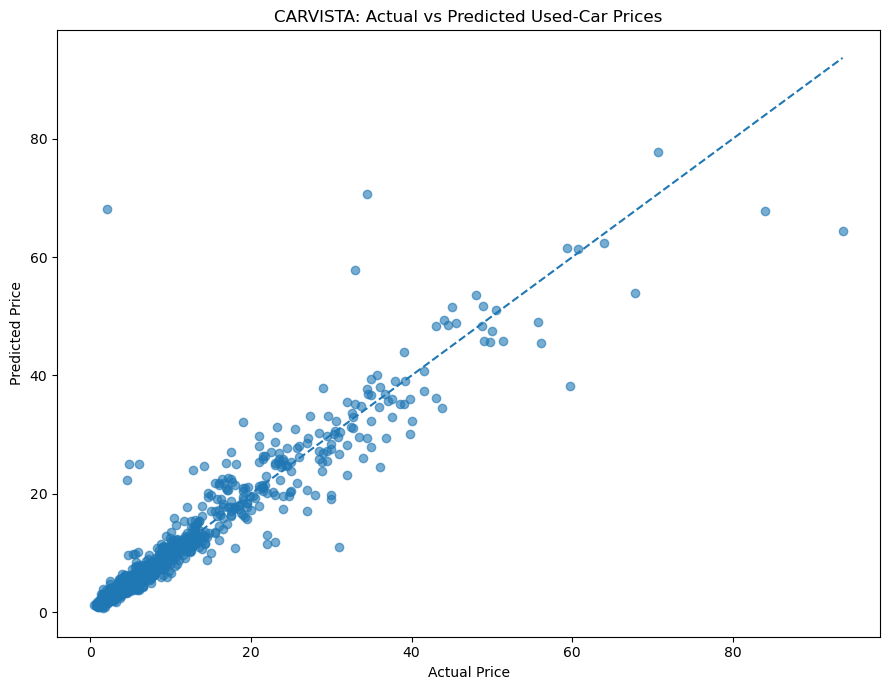

In [58]:
# CARVISTA - ACTUAL VS PREDICTED PRICE

plt.figure(figsize=(9, 7))

plt.scatter(
    y_test_v3,
    y_pred_v3,
    alpha=0.6
)

# Perfect prediction reference line
min_price = min(y_test_v3.min(), y_pred_v3.min())
max_price = max(y_test_v3.max(), y_pred_v3.max())

plt.plot(
    [min_price, max_price],
    [min_price, max_price],
    linestyle="--"
)

plt.xlabel("Actual Price")
plt.ylabel("Predicted Price")
plt.title("CARVISTA: Actual vs Predicted Used-Car Prices")

plt.tight_layout()

plt.savefig(
    "carvista_actual_vs_predicted.svg",
    format="svg",
    bbox_inches="tight"
)

plt.show()

CARVISTA - PERMUTATION FEATURE IMPORTANCE
          Feature  Importance      Std
            Power    8.223520 0.241347
          Car_Age    1.630763 0.102298
             Year    0.653386 0.076361
           Engine    0.646196 0.050927
            Brand    0.411655 0.026977
Kilometers_Driven    0.377913 0.110918
        Car_Model    0.346328 0.015020
     Transmission    0.216369 0.019840
          Mileage    0.148546 0.033975
         Location    0.099711 0.050167
        Fuel_Type    0.030309 0.011269
       Owner_Type    0.002315 0.003228
            Seats   -0.003102 0.012591


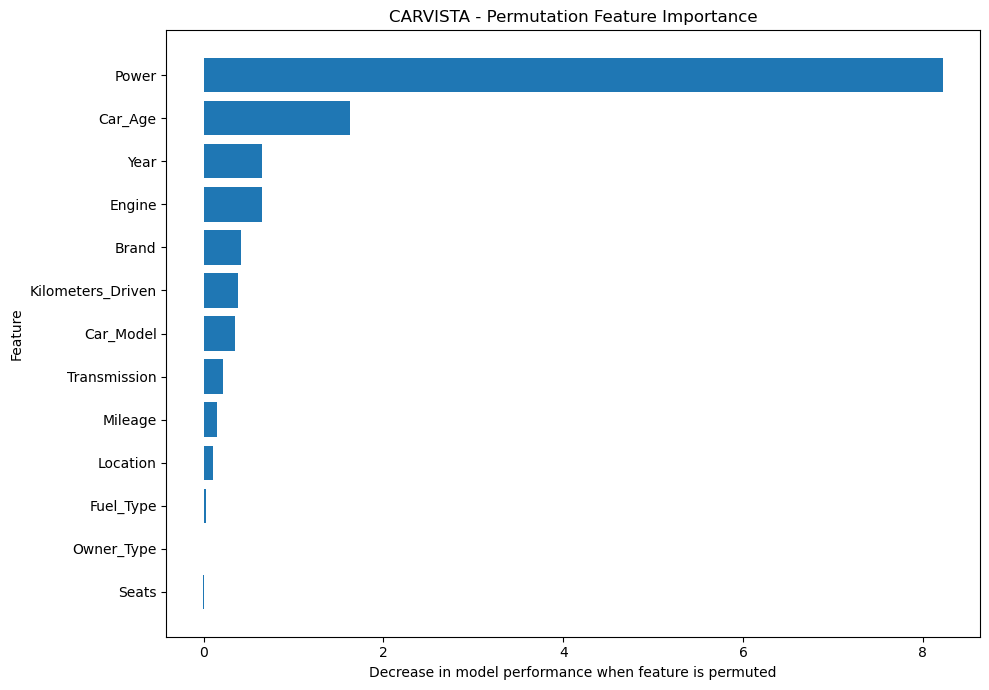

In [59]:
# ============================================================
# CARVISTA - PERMUTATION FEATURE IMPORTANCE
# ============================================================

from sklearn.inspection import permutation_importance
import pandas as pd
import matplotlib.pyplot as plt

# Calculating permutation importance on the untouched test set

perm_result = permutation_importance(
    rf_pipeline_v3,
    X_test_v3,
    y_test_v3,
    n_repeats=10,
    random_state=42,
    scoring="neg_root_mean_squared_error",
    n_jobs=-1
)

# Creating feature importance dataframe

permutation_importance_df = pd.DataFrame({
    "Feature": X_test_v3.columns,
    "Importance": perm_result.importances_mean,
    "Std": perm_result.importances_std
})

# Sorting from highest to lowest

permutation_importance_df = (
    permutation_importance_df
    .sort_values("Importance", ascending=False)
    .reset_index(drop=True)
)

print("=" * 70)
print("CARVISTA - PERMUTATION FEATURE IMPORTANCE")
print("=" * 70)

print(
    permutation_importance_df.to_string(index=False)
)

# Plotingn top 15 features

top_features = (
    permutation_importance_df
    .head(15)
    .sort_values("Importance")
)

plt.figure(figsize=(10, 7))

plt.barh(
    top_features["Feature"],
    top_features["Importance"]
)

plt.xlabel("Decrease in model performance when feature is permuted")
plt.ylabel("Feature")
plt.title("CARVISTA - Permutation Feature Importance")

plt.tight_layout()

plt.savefig(
    "carvista_permutation_importance.svg",
    format="svg",
    bbox_inches="tight"
)

plt.show()

In [60]:
# ============================================================
# CARVISTA - FINAL PREDICTION FUNCTION
# ============================================================

def predict_car_price(
    location,
    fuel_type,
    transmission,
    owner_type,
    year,
    kilometers_driven,
    mileage,
    engine,
    power,
    seats,
    brand,
    car_model
):
    """
    Predict the used-car price using the trained CARVISTA model.
    """

    # Same reference year used during model development
    reference_year = df_clean["Year"].max()

    # Calculate car age
    car_age = reference_year - year

    # Create input dataframe with exactly the features
    # expected by the trained pipeline
    input_data = pd.DataFrame({
        "Location": [location],
        "Fuel_Type": [fuel_type],
        "Transmission": [transmission],
        "Owner_Type": [owner_type],
        "Year": [year],
        "Kilometers_Driven": [kilometers_driven],
        "Mileage": [mileage],
        "Engine": [engine],
        "Power": [power],
        "Seats": [seats],
        "Car_Age": [car_age],
        "Brand": [brand],
        "Car_Model": [car_model]
    })

    # Predict
    predicted_price = rf_pipeline_v3.predict(input_data)[0]

    return predicted_price

In [61]:
# ============================================================
# CARVISTA - SAMPLE PREDICTION TEST
# ============================================================

predicted_price = predict_car_price(
    location="Mumbai",
    fuel_type="Diesel",
    transmission="Automatic",
    owner_type="First",
    year=2018,
    kilometers_driven=45000,
    mileage=18.5,
    engine=1995,
    power=190,
    seats=5,
    brand="BMW",
    car_model="3 Series"
)

print("=" * 60)
print("CARVISTA - USED CAR PRICE PREDICTION")
print("=" * 60)
print(f"Predicted Price: {predicted_price:.2f}")

CARVISTA - USED CAR PRICE PREDICTION
Predicted Price: 33.46


In [62]:
# ============================================================
# CARVISTA - MULTIPLE PREDICTION VALIDATION
# ============================================================

test_cars = [
    {
        "name": "BMW 3 Series",
        "location": "Mumbai",
        "fuel_type": "Diesel",
        "transmission": "Automatic",
        "owner_type": "First",
        "year": 2018,
        "kilometers_driven": 45000,
        "mileage": 18.5,
        "engine": 1995,
        "power": 190,
        "seats": 5,
        "brand": "BMW",
        "car_model": "3 Series"
    },
    
    {
        "name": "Hyundai Santro",
        "location": "Kolkata",
        "fuel_type": "Petrol",
        "transmission": "Manual",
        "owner_type": "First",
        "year": 2012,
        "kilometers_driven": 60000,
        "mileage": 19.0,
        "engine": 1086,
        "power": 62,
        "seats": 5,
        "brand": "Hyundai",
        "car_model": "Santro Xing"
    },
    
    {
        "name": "Toyota Innova",
        "location": "Delhi",
        "fuel_type": "Diesel",
        "transmission": "Manual",
        "owner_type": "First",
        "year": 2016,
        "kilometers_driven": 70000,
        "mileage": 13.5,
        "engine": 2494,
        "power": 102,
        "seats": 7,
        "brand": "Toyota",
        "car_model": "Innova 2.5"
    },
    
    # Intentionally unfamiliar model name
    {
        "name": "Unknown Test Model",
        "location": "Mumbai",
        "fuel_type": "Petrol",
        "transmission": "Manual",
        "owner_type": "First",
        "year": 2017,
        "kilometers_driven": 50000,
        "mileage": 18.0,
        "engine": 1498,
        "power": 100,
        "seats": 5,
        "brand": "UnknownBrand",
        "car_model": "UnknownModel"
    }
]

# ------------------------------------------------------------
# Generate predictions
# ------------------------------------------------------------

results = []

for car in test_cars:

    prediction = predict_car_price(
        location=car["location"],
        fuel_type=car["fuel_type"],
        transmission=car["transmission"],
        owner_type=car["owner_type"],
        year=car["year"],
        kilometers_driven=car["kilometers_driven"],
        mileage=car["mileage"],
        engine=car["engine"],
        power=car["power"],
        seats=car["seats"],
        brand=car["brand"],
        car_model=car["car_model"]
    )

    results.append({
        "Car": car["name"],
        "Predicted_Price": round(prediction, 2)
    })

# ------------------------------------------------------------
# Display results
# ------------------------------------------------------------

results_df = pd.DataFrame(results)

print("=" * 60)
print("CARVISTA - MULTIPLE CAR PREDICTIONS")
print("=" * 60)

print(results_df.to_string(index=False))

CARVISTA - MULTIPLE CAR PREDICTIONS
               Car  Predicted_Price
      BMW 3 Series            33.46
    Hyundai Santro             2.04
     Toyota Innova            12.86
Unknown Test Model             7.90


In [63]:
# ============================================================
# CARVISTA - SAVE TRAINED PIPELINE
# ============================================================

import os
import joblib

# CARVISTA project directory
project_path = r"C:\Users\gayat\OneDrive\Desktop\CARVISTA"

# Model directory
model_dir = os.path.join(project_path, "models")

# Create models folder if it doesn't already exist
os.makedirs(model_dir, exist_ok=True)

# Path for saved pipeline
model_path = os.path.join(
    model_dir,
    "carvista_rf_pipeline.joblib"
)

# Save the complete trained pipeline
joblib.dump(
    rf_pipeline_v3,
    model_path
)

print("=" * 70)
print("CARVISTA - MODEL SAVED")
print("=" * 70)

print(f"\nModel saved successfully:")
print(model_path)

print(f"\nFile exists: {os.path.exists(model_path)}")

if os.path.exists(model_path):
    print(
        f"File size: "
        f"{os.path.getsize(model_path) / 1024 / 1024:.2f} MB"
    )

CARVISTA - MODEL SAVED

Model saved successfully:
C:\Users\gayat\OneDrive\Desktop\CARVISTA\models\carvista_rf_pipeline.joblib

File exists: True
File size: 115.92 MB


In [64]:
# ============================================================
# CARVISTA - VERIFY SAVED PIPELINE
# ============================================================

loaded_model = joblib.load(model_path)

# Use the same sample car
sample_input = pd.DataFrame({
    "Location": ["Mumbai"],
    "Fuel_Type": ["Diesel"],
    "Transmission": ["Automatic"],
    "Owner_Type": ["First"],
    "Year": [2018],
    "Kilometers_Driven": [45000],
    "Mileage": [18.5],
    "Engine": [1995],
    "Power": [190],
    "Seats": [5],
    "Car_Age": [df_clean["Year"].max() - 2018],
    "Brand": ["BMW"],
    "Car_Model": ["3 Series"]
})

loaded_prediction = loaded_model.predict(sample_input)[0]

print("=" * 70)
print("CARVISTA - SAVED MODEL VERIFICATION")
print("=" * 70)

print(f"\nPrediction from saved model: {loaded_prediction:.2f}")
print(f"Original prediction:         {predicted_price:.2f}")

print(
    "\nPredictions match:",
    abs(loaded_prediction - predicted_price) < 1e-10
)

CARVISTA - SAVED MODEL VERIFICATION

Prediction from saved model: 33.46
Original prediction:         33.46

Predictions match: True


In [65]:
# ============================================================
# CARVISTA - SAVE APPLICATION METADATA
# ============================================================

import json
import os

# ------------------------------------------------------------
# Reference year used when creating Car_Age
# ------------------------------------------------------------

reference_year = int(df_clean["Year"].max())

# ------------------------------------------------------------
# Collect valid categorical values
# ------------------------------------------------------------
metadata = {
    "reference_year": reference_year,
    "brand_model_map": brand_model_map,

    "categorical_values": {
        "Location": sorted(
            model_df_v3["Location"].dropna().unique().tolist()
        ),

        "Fuel_Type": sorted(
            model_df_v3["Fuel_Type"].dropna().unique().tolist()
        ),

        "Transmission": sorted(
            model_df_v3["Transmission"].dropna().unique().tolist()
        ),

        "Owner_Type": sorted(
            model_df_v3["Owner_Type"].dropna().unique().tolist()
        ),

        "Brand": sorted(
            model_df_v3["Brand"].dropna().unique().tolist()
        ),

        "Car_Model": sorted(
            model_df_v3["Car_Model"].dropna().unique().tolist()
        )
    },

    # --------------------------------------------------------
    # Numerical ranges for application validation
    # --------------------------------------------------------

    "numerical_ranges": {
        "Year": {
            "min": int(model_df_v3["Year"].min()),
            "max": int(model_df_v3["Year"].max())
        },

        "Kilometers_Driven": {
            "min": float(model_df_v3["Kilometers_Driven"].min()),
            "max": float(model_df_v3["Kilometers_Driven"].max())
        },

        "Mileage": {
            "min": float(model_df_v3["Mileage"].min()),
            "max": float(model_df_v3["Mileage"].max())
        },

        "Engine": {
            "min": float(model_df_v3["Engine"].min()),
            "max": float(model_df_v3["Engine"].max())
        },

        "Power": {
            "min": float(model_df_v3["Power"].min()),
            "max": float(model_df_v3["Power"].max())
        },

        "Seats": {
            "min": int(model_df_v3["Seats"].min()),
            "max": int(model_df_v3["Seats"].max())
        }
    }
}

# ------------------------------------------------------------
# Save metadata
# ------------------------------------------------------------

metadata_path = os.path.join(
    model_dir,
    "carvista_metadata.json"
)

with open(metadata_path, "w", encoding="utf-8") as f:
    json.dump(
        metadata,
        f,
        indent=4
    )

print("=" * 70)
print("CARVISTA - METADATA SAVED")
print("=" * 70)

print(f"\nMetadata saved to:")
print(metadata_path)

print(f"\nReference year: {reference_year}")

print(
    f"Number of brands: "
    f"{len(metadata['categorical_values']['Brand'])}"
)

print(
    f"Number of car models: "
    f"{len(metadata['categorical_values']['Car_Model'])}"
)

print(
    f"Number of locations: "
    f"{len(metadata['categorical_values']['Location'])}"
)

CARVISTA - METADATA SAVED

Metadata saved to:
C:\Users\gayat\OneDrive\Desktop\CARVISTA\models\carvista_metadata.json

Reference year: 2019
Number of brands: 30
Number of car models: 655
Number of locations: 11


In [66]:
# Create Brand -> Car_Model mapping for the Streamlit app

brand_model_map = (
    model_df_v3.groupby("Brand")["Car_Model"]
    .unique()
    .apply(sorted)
    .to_dict()
)

brand_model_map = {
    brand: list(models)
    for brand, models in brand_model_map.items()
}

print("Number of brands:", len(brand_model_map))

Number of brands: 30


In [67]:
import streamlit

print("Streamlit version:", streamlit.__version__)

Streamlit version: 1.45.1
